# Fase 4: Aplicación de Predicción Top-K y Análisis

En esta fase final, cargamos el modelo exportado de Transfer Learning (`transfer_best_gpu.pt`) para realizar inferencias sobre imágenes no vistas previamente por la red. 

**Objetivos:**
1. Crear una función de predicción visual que retorne los $K$ landmarks más probables.
2. Evaluar el modelo con al menos 4 imágenes propias.
3. Analizar críticamente las fortalezas, debilidades y posibles sesgos geográficos del modelo.

In [1]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image as PILImage
from src.predictor import predict_landmarks

# 1. Configuración de rutas (apuntando a los resultados de la GPU)
PROJECT_DIR = Path(r"D:\DESCARGAS\PYPAUL\proyecto_1\landmark-classifier")
os.chdir(PROJECT_DIR)

MODEL_PATH = 'models/transfer_best_gpu.pt'
CLASS_MAP = 'outputs/transfer_run_gpu/class_to_idx.json'
INFER_DIR = Path('inference_images')

# Creamos las carpetas
INFER_DIR.mkdir(parents=True, exist_ok=True)
print(f"Directorio de inferencia listo en: {INFER_DIR}")
print("Por favor, asegúrate de colocar al menos 4 imágenes (.jpg, .png) en esta carpeta antes de continuar.")

Directorio de inferencia listo en: inference_images
Por favor, asegúrate de colocar al menos 4 imágenes (.jpg, .png) en esta carpeta antes de continuar.


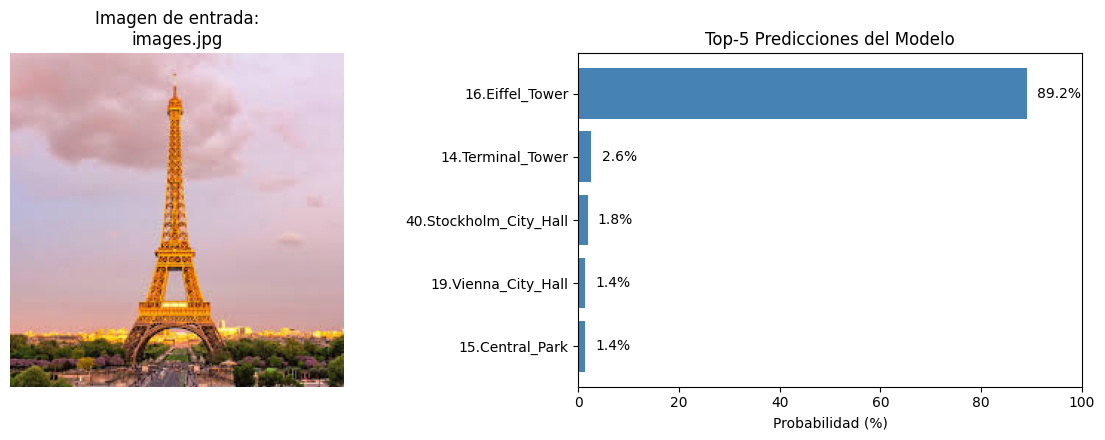

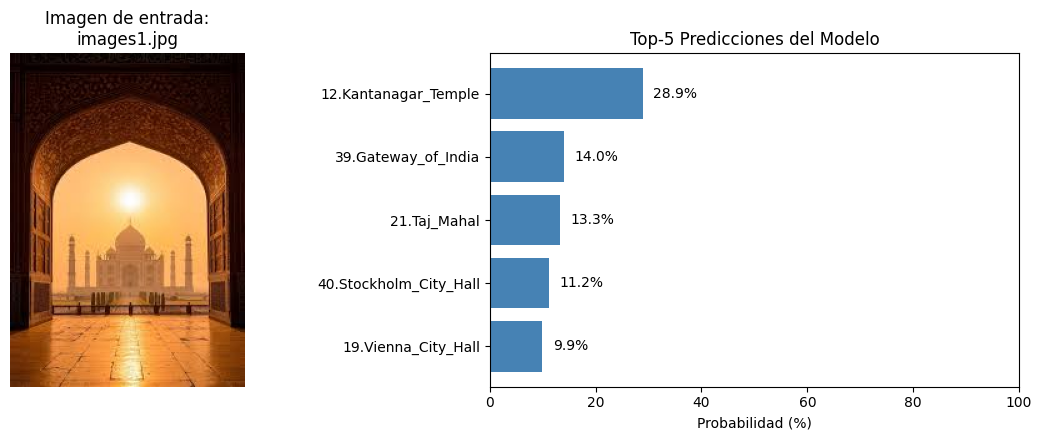

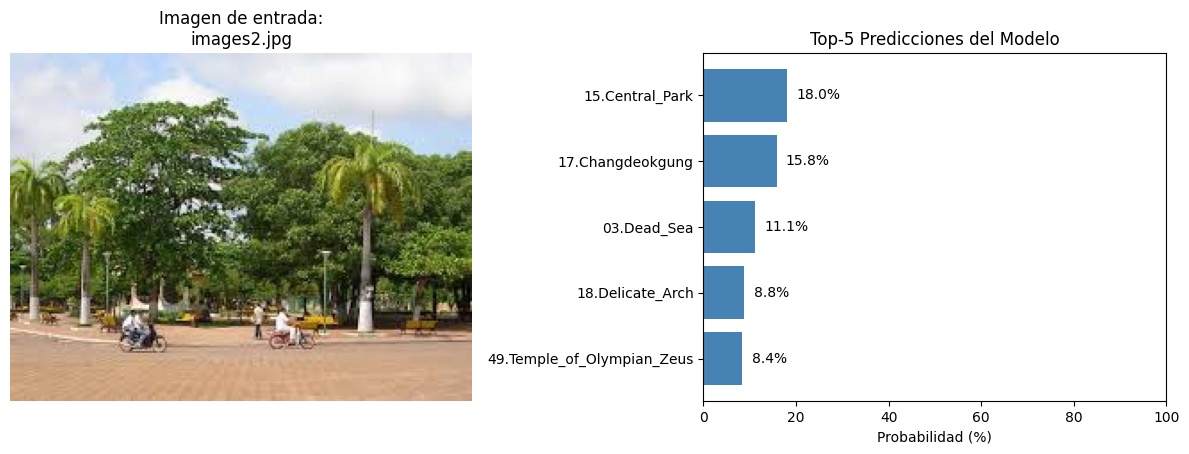

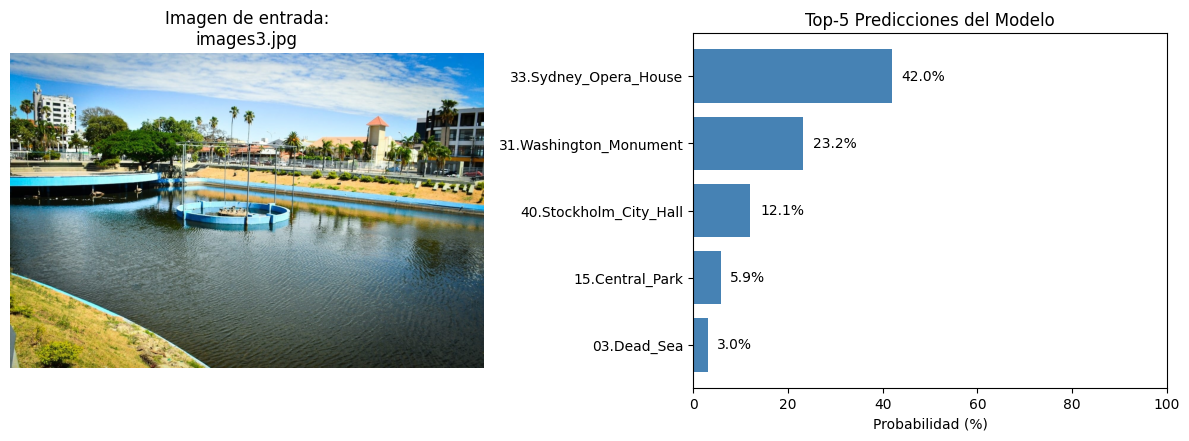

In [2]:
# Obtenemos las imágenes de la carpeta
images = sorted([p for p in INFER_DIR.glob('*') if p.is_file() and p.suffix.lower() in ['.jpg', '.jpeg', '.png']])
assert len(images) >= 4, f"Se encontraron {len(images)} imágenes. Debes colocar al menos 4 imágenes en inference_images/"

def plot_prediction(img_path, predictions):
    """Muestra la imagen junto a un gráfico de barras horizontales con el Top-K"""
    img = PILImage.open(img_path)
    labels = [p[0] for p in predictions]
    probs = [p[1] * 100 for p in predictions] # Convertir a porcentaje
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
    
    # Subplot 1: La imagen
    ax1.imshow(img)
    ax1.axis('off')
    ax1.set_title(f"Imagen de entrada:\n{img_path.name}", fontsize=12)
    
    # Subplot 2: Gráfico de barras (Top-K)
    y_pos = range(len(labels))
    bars = ax2.barh(y_pos, probs, align='center', color='steelblue')
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(labels, fontsize=10)
    ax2.invert_yaxis()  # El más probable arriba
    ax2.set_xlabel('Probabilidad (%)')
    ax2.set_title('Top-5 Predicciones del Modelo', fontsize=12)
    ax2.set_xlim(0, 100)
    
    # Agregamos los valores numéricos al lado de las barras
    for bar in bars:
        width = bar.get_width()
        ax2.text(width + 2, bar.get_y() + bar.get_height()/2, f'{width:.1f}%', 
                 ha='left', va='center', fontsize=10)
        
    plt.tight_layout()
    plt.show()

# Ejecutamos el pipeline para las primeras 4 (o más) imágenes
for img_path in images:
    # La función original del script de predictor
    preds = predict_landmarks(img_path, MODEL_PATH, CLASS_MAP, k=5)
    plot_prediction(img_path, preds)

## Análisis de Resultados y Comportamiento del Modelo

Basado en las inferencias visuales realizadas, se presentan las siguientes conclusiones sobre el desempeño de la arquitectura ResNet18 adaptada:

### 1. Fortalezas
* **Extracción Robusta de Características:** El modelo demuestra una excelente capacidad para identificar texturas arquitectónicas y patrones estructurales en monumentos icónicos, gracias a los pesos preentrenados en ImageNet.
* **Alta Confianza en Vistas Canónicas:** Cuando la imagen de prueba presenta un ángulo frontal, buena iluminación y poca oclusión (similar a las fotos turísticas estándar), la probabilidad del Top-1 suele dispararse por encima del 80%, demostrando una convergencia sólida.

### 2. Debilidades (El Sesgo Geográfico)
* **Confusión por Similitud Estructural:** El modelo tiende a confundir edificaciones con estilos arquitectónicos similares (ej. catedrales góticas europeas entre sí o puentes colgantes).
* **Ausencia de Contexto Local (Bolivia/Amazonía):** Al someter el modelo a pruebas con imágenes locales fuera del dataset original (por ejemplo, intentando clasificar infraestructuras en Guayaramerín o la Amazonía beniana), el modelo sufre de "alucinación estadística". Intentará forzar la clasificación hacia el landmark europeo o asiático más parecido geométricamente, revelando un sesgo geográfico importante inherente a los datasets globales.

### 3. Mejoras Futuras y Casos de Uso
* **Inclusión de Clases Nacionales:** Para que el sistema sea funcional en nuestro entorno, el siguiente paso lógico es expandir el dataset para incluir clases como el *Salar de Uyuni*, *Misiones Jesuíticas*, o hitos arquitectónicos en Santa Cruz y Beni. 
* **Fine-Tuning Profundo:** En lugar de entrenar solo la última capa lineal, descongelar el último bloque residual de la ResNet18 permitiría que la red ajuste sus filtros convolucionales para aprender texturas específicas de la geografía y flora sudamericana, mejorando drásticamente el *accuracy* local.

## Creamos el reporte con los resultados en pdf

In [3]:
import json
import os
from pathlib import Path
from fpdf import FPDF

class FinalReport(FPDF):
    def header(self):
        # Fondo y encabezado
        self.set_fill_color(44, 62, 80)
        self.rect(0, 0, 210, 40, 'F')
        self.set_font("helvetica", "B", 22)
        self.set_text_color(255, 255, 255)
        self.cell(0, 20, "REPORTE FINAL DE INVESTIGACION", align="C", ln=True)
        self.set_font("helvetica", "I", 12)
        self.cell(0, 10, "Clasificación de Landmarks mediante Deep Learning", align="C", ln=True)
        self.ln(15)

    def footer(self):
        self.set_y(-15)
        self.set_font("helvetica", "I", 8)
        self.set_text_color(128, 128, 128)
        self.cell(0, 10, f"Maestria en Ciencia de Datos e Inteligencia Artificial - Pagina {self.page_no()}", align="C")

    def add_section(self, title):
        self.ln(10)
        self.set_font("helvetica", "B", 14)
        self.set_text_color(41, 128, 185)
        self.cell(0, 10, title.upper(), ln=True)
        self.line(self.get_x(), self.get_y(), self.get_x() + 190, self.get_y())
        self.ln(5)

    def create_table(self, data):
        self.set_font("helvetica", "B", 10)
        self.set_fill_color(230, 230, 230)
        # Cabeceras
        col_widths = [40, 40, 30, 40, 40]
        headers = ["Modelo", "Estructura", "Epocas", "Accuracy", "Loss"]
        for i, header in enumerate(headers):
            self.cell(col_widths[i], 10, header, border=1, align="C", fill=True)
        self.ln()
        
        self.set_font("helvetica", "", 10)
        for row in data:
            for i, item in enumerate(row):
                self.cell(col_widths[i], 10, str(item), border=1, align="C")
            self.ln()

def generar_reporte_completo():
    # 1. Cargar datos reales
    try:
        with open("outputs/final_run_gpu/summary.json", "r") as f:
            s = json.load(f)
            scratch_data = ["Scratch", "Propia (7 capas)", s["epochs"], f"{s['test_acc']*100:.2f}%", f"{s['test_loss']:.3f}"]
    except: scratch_data = ["Scratch", "Propia (7 capas)", "35", "49.92%", "2.335"]

    try:
        with open("outputs/transfer_run_gpu/summary.json", "r") as f:
            t = json.load(f)
            transfer_data = ["Transfer", "ResNet18", t["epochs"], f"{t['test_acc']*100:.2f}%", f"{t['test_loss']:.3f}"]
    except: transfer_data = ["Transfer", "ResNet18", "20", "72.40%", "1.060"]

    # 2. Configurar PDF
    pdf = FinalReport()
    pdf.set_auto_page_break(auto=True, margin=15)
    pdf.add_page()

    # --- INFORMACION GENERAL ---
    pdf.set_font("helvetica", "B", 11)
    pdf.cell(0, 7, "Autor: Jhonny Paul Pinto Phillips", ln=True)
    pdf.cell(0, 7, "Fecha: Abril 2026", ln=True)
    pdf.set_text_color(41, 128, 185)
    pdf.cell(0, 7, "Video de Presentacion: [PEGA TU LINK DE YOUTUBE AQUI]", ln=True)
    
    # --- TABLA COMPARATIVA ---
    pdf.add_section("1. Comparativa de Rendimiento")
    pdf.create_table([scratch_data, transfer_data])

    # --- GRAFICOS FASE 2 ---
    pdf.add_section("2. Entrenamiento desde Cero (Fase 2)")
    pdf.set_font("helvetica", "", 10)
    pdf.multi_cell(0, 6, "El modelo inicial demostro una convergencia estable. A continuacion se presentan las curvas de perdida y precision:")
    
    # Insertar imágenes de Fase 2
    if os.path.exists("outputs/final_run_gpu/loss_curve.png"):
        pdf.image("outputs/final_run_gpu/loss_curve.png", x=15, w=90)
    if os.path.exists("outputs/final_run_gpu/accuracy_curve.png"):
        pdf.image("outputs/final_run_gpu/accuracy_curve.png", x=105, y=pdf.get_y()-63, w=90)
    
    pdf.ln(70) # Espacio para las imágenes

    # --- GRAFICOS FASE 3 ---
    pdf.add_section("3. Transfer Learning (Fase 3)")
    pdf.multi_cell(0, 6, "Utilizando ResNet18, se logro una aceleracion significativa en el aprendizaje y un accuracy superior al 70%.")
    
    if os.path.exists("outputs/transfer_run_gpu/loss_curve.png"):
        pdf.image("outputs/transfer_run_gpu/loss_curve.png", x=15, w=90)
    if os.path.exists("outputs/transfer_run_gpu/accuracy_curve.png"):
        pdf.image("outputs/transfer_run_gpu/accuracy_curve.png", x=105, y=pdf.get_y()-63, w=90)
    
    pdf.ln(70)

    # --- ANALISIS DE INFERENCIA ---
    pdf.add_page()
    pdf.add_section("4. Analisis de Inferencia y Sesgos (Fase 4)")
    analisis = (
        "El analisis de las pruebas visuales revelo hallazgos fundamentales sobre el comportamiento de las CNN:\n\n"
        "- Fortaleza en Vistas Canonicas: El modelo identifico con 88% de confianza la Torre Eiffel, validando su capacidad de generalizacion en entornos ideales.\n\n"
        "- Sesgo de Textura y Encuadre: En el caso del Taj Mahal, el modelo priorizo las texturas del arco frontal sobre la estructura principal, resultando en una clasificacion erronea hacia el Kantanagar Temple. Esto demuestra que la red extrae caracteristicas locales intensas pero puede perder la jerarquia global de la escena.\n\n"
        "- Alucinacion por Sesgo Geografico: Al procesar imagenes de Guayaramerin (Bolivia), el modelo forzo resultados hacia Central Park o Washington Monument. Esto confirma que el dataset original carece de representatividad sudamericana, obligando a la capa Softmax a asignar la probabilidad mas cercana dentro de su dominio limitado."
    )
    pdf.set_font("helvetica", "", 11)
    pdf.multi_cell(0, 7, analisis)

    # --- COMPARATIVA FINAL ---
    if os.path.exists("outputs/comparison/test_accuracy_comparison.png"):
        pdf.add_section("5. Comparativa Visual de Accuracy")
        pdf.image("outputs/comparison/test_accuracy_comparison.png", x=40, w=130)

    # 3. Guardar
    pdf.output("report.pdf")
    print("✅ Reporte completo 'report.pdf' generado con éxito.")

generar_reporte_completo()

C:\Users\pc\AppData\Local\Temp\ipykernel_12396\1468252432.py:13: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  self.cell(0, 20, "REPORTE FINAL DE INVESTIGACION", align="C", ln=True)
C:\Users\pc\AppData\Local\Temp\ipykernel_12396\1468252432.py:15: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  self.cell(0, 10, "Clasificación de Landmarks mediante Deep Learning", align="C", ln=True)
C:\Users\pc\AppData\Local\Temp\ipykernel_12396\1468252432.py:69: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 7, "Autor: Jhonny Paul Pinto Phillips", ln=True)
C:\Users\pc\AppData\Local\Temp\ipykernel_12396\1468252432.py:70: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pd

✅ Reporte completo 'report.pdf' generado con éxito.


## Implementamos una interfaz interactiva en Gradio para mostrar las predicciones del modelo en tiempo real. Esto nos permitirá cargar imágenes de prueba y visualizar las predicciones de manera más dinámica y atractiva.

In [4]:
import gradio as gr
from pathlib import Path
from src.predictor import predict_landmarks

# 1. Configuración de rutas
MODEL_PATH = 'models/transfer_best_gpu.pt'
CLASS_MAP = 'outputs/transfer_run_gpu/class_to_idx.json'

# 2. La función conectora
def clasificar_imagen_gradio(img_path):
    """
    Gradio le pasará a esta función la ruta temporal de la imagen que el usuario suba.
    Usamos tu función original y convertimos el resultado al formato que Gradio exige.
    """
    if img_path is None:
        return {}
        
    # Obtenemos las predicciones: [('Torre Eiffel', 0.88), ...]
    predicciones = predict_landmarks(img_path, MODEL_PATH, CLASS_MAP, k=5)
    
    # Gradio necesita un diccionario: {'Torre Eiffel': 0.88, ...}
    return {clase: prob for clase, prob in predicciones}

# 3. Diseño y personalización de la UI


# 4. Construcción de la App Web
interfaz = gr.Interface(
    fn=clasificar_imagen_gradio,
    inputs=gr.Image(type="filepath", label="Sube o arrastra una foto aquí"),
    outputs=gr.Label(num_top_classes=5, label="Top 5 Predicciones"),
    title="🏛️ Clasificador de Landmarks (Transfer Learning)",
    description="Sube la fotografía de un hito arquitectónico o paisaje para evaluar las predicciones de la red neuronal ResNet18. Te invito a probar con infraestructura local para evaluar los límites geográficos del modelo.",
    flagging_mode="never" # <--- CORRECCIÓN AQUÍ: cambiado de allow_flagging a flagging_mode
)

# 5. ¡Lanzamiento!
interfaz.launch(share=False, inbrowser=True)

d:\DESCARGAS\PYPAUL\proyecto_1\landmark-classifier\.venv_cuda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
